# Supplementary figures — copied from `../2SLS.ipynb`

**This is a near-verbatim copy of the source notebook**, not a cleaned
reproduction. Only inert cells were removed: empty cells, cells that are
entirely commented out, and cells that only `print()` or display a table.
Every cell that computes or plots anything is untouched.

Panels produced here: `2SLS_muscle`(`_median`,`_pvals`,`_pvals_median`), `BaronKenny_muscle`(`_median`), `MR_2SLS.slopes`

Two mechanical path edits were applied so the notebook runs from this directory
and cannot overwrite the published figures:

* `../code/...` → `../../code/...` (this notebook sits one level deeper)
* `../code/plots/` → `plots/` and `../code/revision_plots/` → `revision_plots/`

Cells unrelated to the supplementary panels were **kept**, so this notebook may
compute more than it needs to. That is the trade for not re-tracing it.

In [1]:
import pandas as pd
import numpy as np
import gzip
import pysam
import linearmodels
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [2]:
def get_cumulative(x, steps = 100):
    '''
    Function to get cumulative distribution.
    '''
    x = np.array(x)
    X = np.linspace(np.min(x), np.max(x), steps)
    y = [np.mean(x<=z) for z in X]
    return X, y

def prepare_qq(y_):

    min_non_zero = np.min([x for x in y_ if x > 0])

    y_ = np.maximum(np.array(y_), min_non_zero)
    y = sorted(-np.log10(np.array(y_)))
    x = sorted(-np.log10(np.linspace(1, len(y)+1, len(y))/len(y)))
    return x, y
    

In [3]:
tissues = sorted(os.listdir('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/'))

In [4]:
testis_pr = pd.read_csv('../../code/results/mr_2sls/Cells-Culturedfibroblasts_PR.tab.gz', sep='\t')
testis_up = pd.read_csv('../../code/results/mr_2sls/Cells-Culturedfibroblasts_UP.tab.gz', sep='\t')

mx_up, my_up = get_cumulative(testis_up.loc[(testis_up.F >= 10) & (testis_up.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
mx_pr, my_pr = get_cumulative(testis_pr.loc[(testis_pr.F >= 10) & (testis_pr.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())

x_up, y_up = get_cumulative(testis_up.loc[testis_up.F >= 10].intron_gene_beta)
x_pr, y_pr = get_cumulative(testis_pr.loc[testis_pr.F >= 10].intron_gene_beta)




Text(0.5, 1.0, '2SLS (Muscle - Skeletal), eQTL pval <= 1e-10')

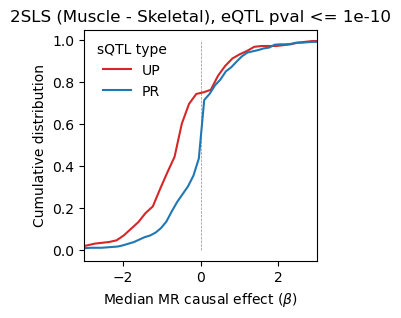

In [5]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(mx_up, my_up, c='tab:red', label='UP')
ax.plot(mx_pr, my_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal), eQTL pval <= 1e-10')

In [6]:
sqtl_stats = pd.read_csv('../../code/analysis_files/sQTL_stats.tsv.gz', sep='\t')

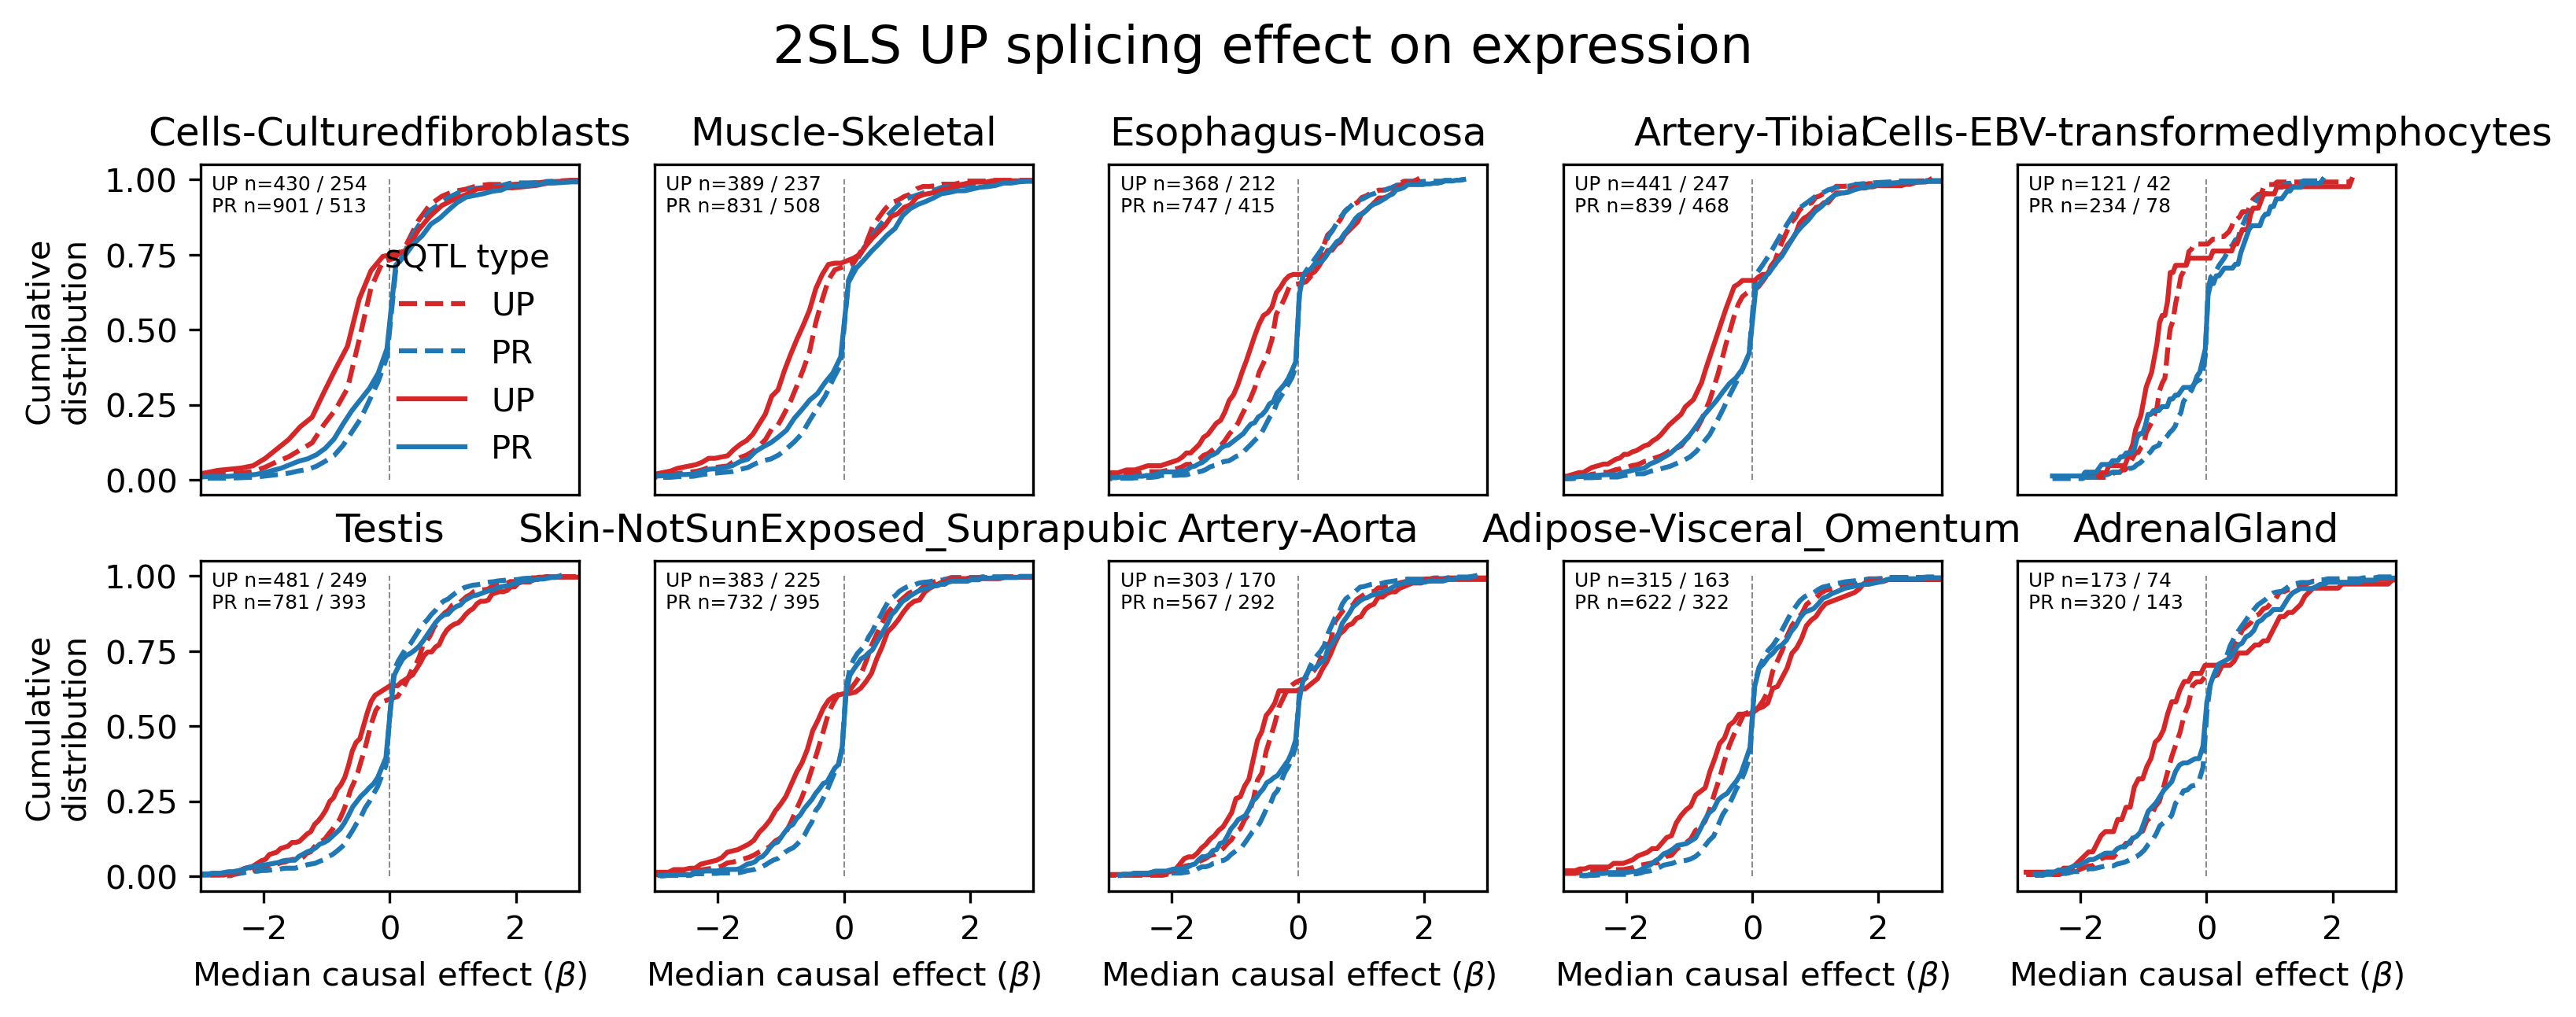

In [14]:
fig, ax = plt.subplots(2, 5, figsize=(12, 4), dpi=300)
i = 0
j = 0

sorted_tissues = list(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].sort_values('spearman_pval').tissue)

for tissue in sorted_tissues[:10]:


    tissue_pr = pd.read_csv(f'../../code/results/mr_2sls/{tissue}_PR.tab.gz', sep='\t')
    tissue_up = pd.read_csv(f'../../code/results/mr_2sls/{tissue}_UP.tab.gz', sep='\t')
    
    mx_up, my_up = get_cumulative(tissue_up.loc[(tissue_up.F >= 10) & (tissue_up.pval1 <= 1e-4)].groupby('gene').intron_gene_beta.median())
    mx_pr, my_pr = get_cumulative(tissue_pr.loc[(tissue_pr.F >= 10) & (tissue_pr.pval1 <= 1e-4)].groupby('gene').intron_gene_beta.median())


    n_up1 = len(tissue_up.loc[(tissue_up.F >= 10) & (tissue_up.pval1 <= 1e-4)].groupby('gene').intron_gene_beta)
    n_pr1 = len(tissue_pr.loc[(tissue_pr.F >= 10) & (tissue_pr.pval1 <= 1e-4)].groupby('gene').intron_gene_beta.median())
    
    # x_up, y_up = get_cumulative(tissue_up.loc[tissue_up.F >= 10].intron_gene_beta)
    # x_pr, y_pr = get_cumulative(tissue_pr.loc[tissue_pr.F >= 10].intron_gene_beta)



    

    ax[i,j].plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
    
    _n_up_lenient, _n_pr_lenient = len(mx_up), len(mx_pr)   # p <= 1e-4, dashed
    ax[i,j].plot(mx_up, my_up, c='tab:red', label='UP', linestyle='--')
    ax[i,j].plot(mx_pr, my_pr, c='tab:blue', label='PR', linestyle='--')


    mx_up, my_up = get_cumulative(tissue_up.loc[(tissue_up.F >= 10) & (tissue_up.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
    mx_pr, my_pr = get_cumulative(tissue_pr.loc[(tissue_pr.F >= 10) & (tissue_pr.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())

    n_up2 = len(tissue_up.loc[(tissue_up.F >= 10) & (tissue_up.pval1 <= 1e-10)].groupby('gene').intron_gene_beta)
    n_pr2 = len(tissue_pr.loc[(tissue_pr.F >= 10) & (tissue_pr.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())


    ax[i,j].plot(mx_up, my_up, c='tab:red', label='UP')
    ax[i,j].plot(mx_pr, my_pr, c='tab:blue', label='PR')
    
    ax[i,j].set_xlim([-3, 3])

    if (i == 0) and (j == 0):
        ax[i,j].legend(frameon=False, title='sQTL type')

    
    if j == 0:
        ax[i,j].set_ylabel('Cumulative\ndistribution', size=10)
    else:
        ax[i,j].set_yticks([])
    
    
        
    if (i == 1):
        ax[i,j].set_xlabel('Median causal effect $(\\beta)$', size=10)
        # ax[i,j].set_xticks([-1, 0, 1, 2], ['0.1%', '1%', '10%', '100%'])
    else:
        ax[i,j].set_xticks([])  

    # Genes behind each curve. Two thresholds are drawn per series, so both
    # counts are given: solid is p <= 1e-10, dashed p <= 1e-4.
    ax[i,j].text(0.03, 0.97,
                 f'UP n={n_up1} / {n_up2}\nPR n={n_pr1} / {n_pr2}',
                 transform=ax[i,j].transAxes, ha='left', va='top', fontsize=6)
    ax[i,j].set_title(tissue, size=12)

    j += 1
    if j >= 5:
        j = 0
        i += 1

fig.suptitle(r"2SLS UP splicing effect on expression", fontsize=16, y = 1.03)


plt.savefig('revision_plots/MR_2SLS.slopes.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/MR_2SLS.slopes.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/MR_2SLS.slopes.svg', dpi=300, bbox_inches='tight')    

Text(0.5, 1.03, '2SLS UP splicing effect on expression, eQTL pval $\\leq 1e^{-10}$')

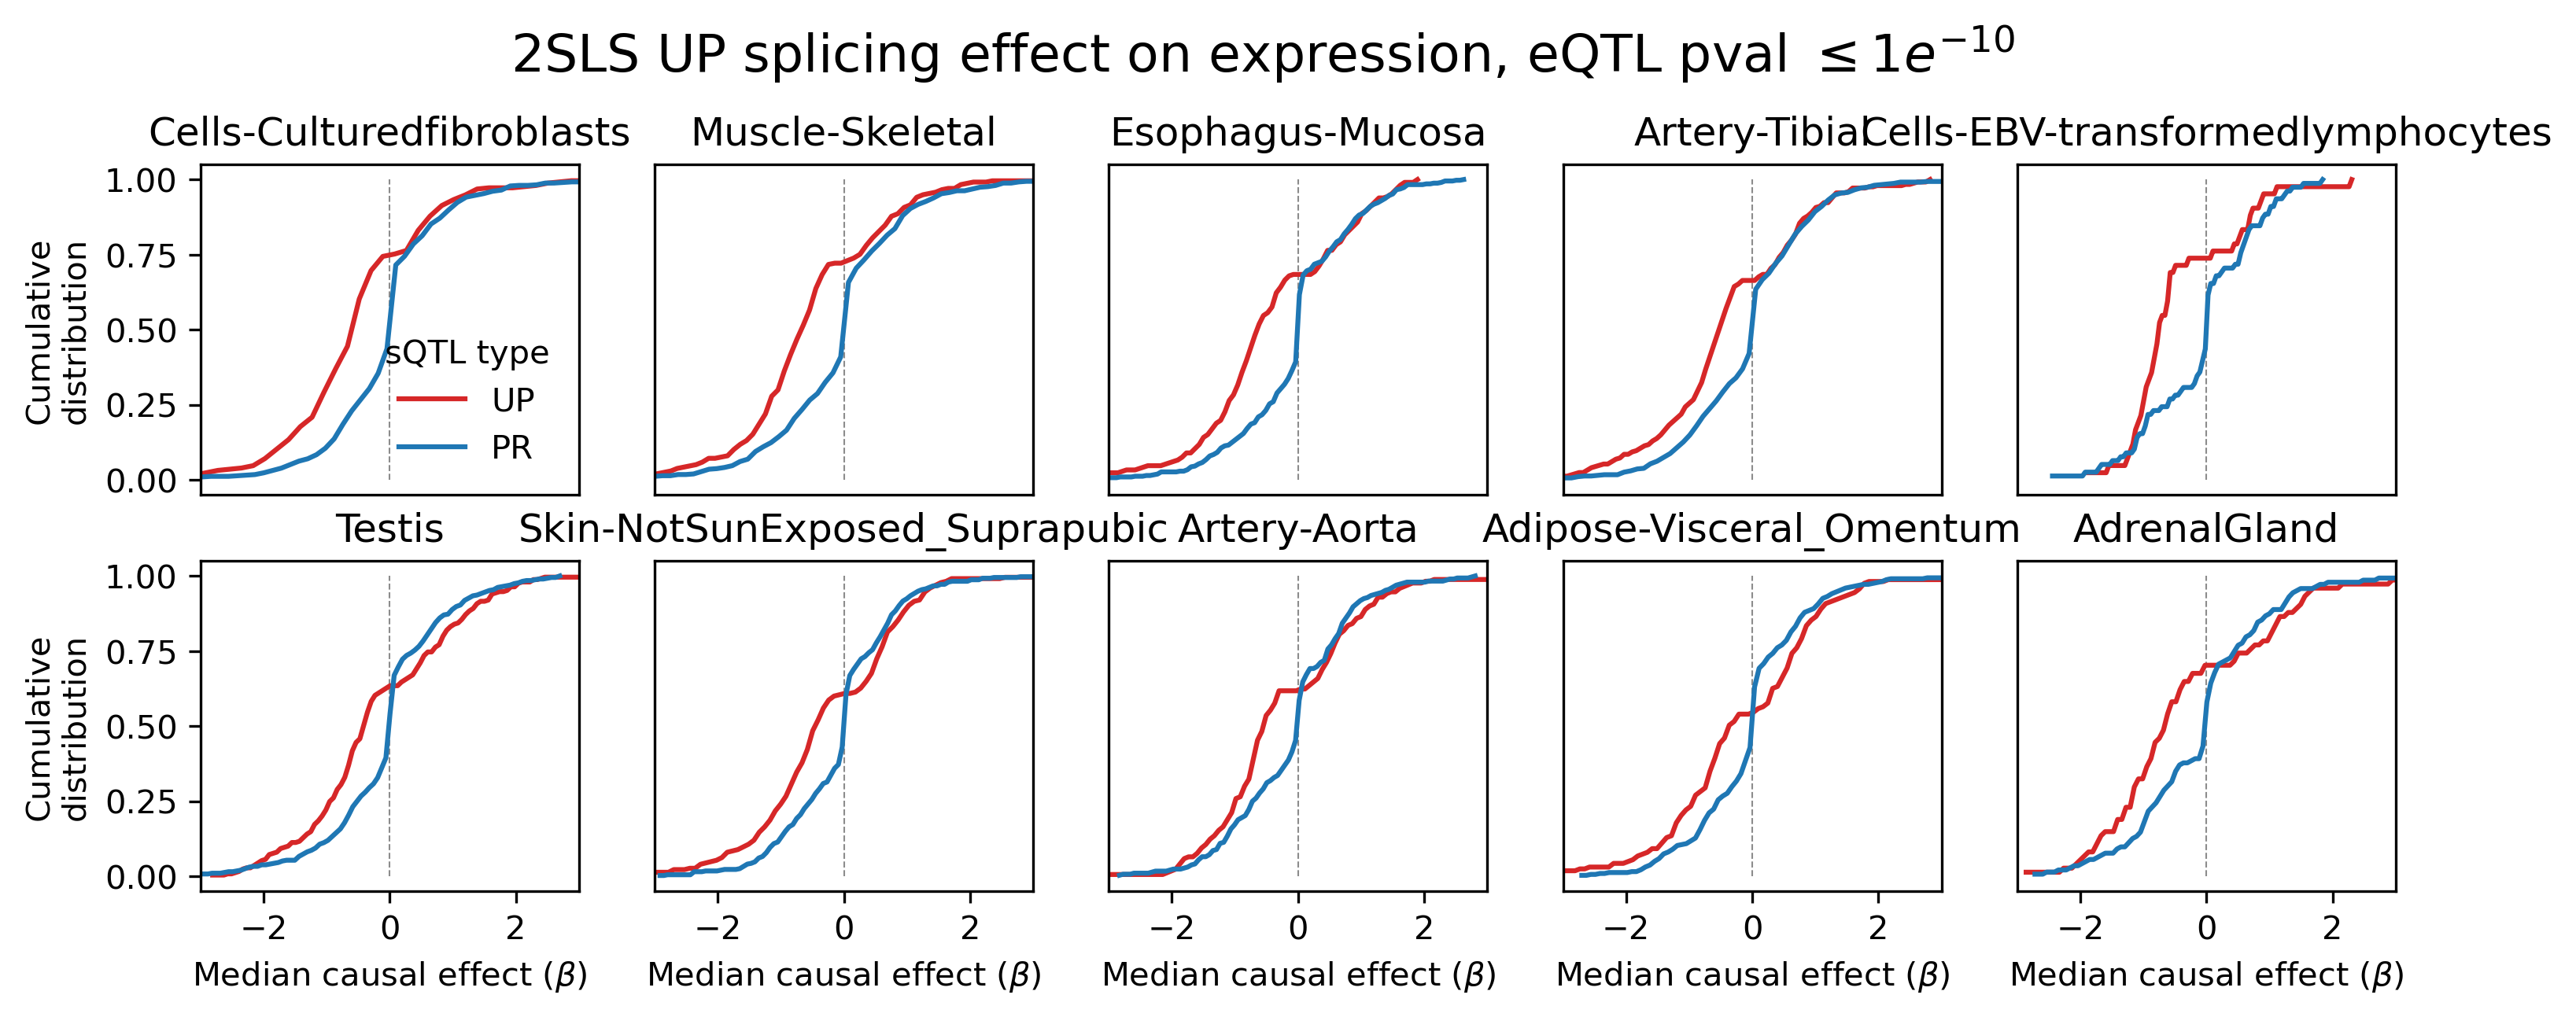

In [8]:
fig, ax = plt.subplots(2, 5, figsize=(12, 4), dpi=300)
i = 0
j = 0

sorted_tissues = list(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].sort_values('spearman_pval').tissue)

for tissue in sorted_tissues[:10]:


    tissue_pr = pd.read_csv(f'../../code/results/mr_2sls/{tissue}_PR.tab.gz', sep='\t')
    tissue_up = pd.read_csv(f'../../code/results/mr_2sls/{tissue}_UP.tab.gz', sep='\t')
    
    mx_up, my_up = get_cumulative(tissue_up.loc[(tissue_up.F >= 10) & (tissue_up.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
    mx_pr, my_pr = get_cumulative(tissue_pr.loc[(tissue_pr.F >= 10) & (tissue_pr.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
    
    # x_up, y_up = get_cumulative(tissue_up.loc[tissue_up.F >= 10].intron_gene_beta)
    # x_pr, y_pr = get_cumulative(tissue_pr.loc[tissue_pr.F >= 10].intron_gene_beta)


    

    ax[i,j].plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
    
    ax[i,j].plot(mx_up, my_up, c='tab:red', label='UP')
    ax[i,j].plot(mx_pr, my_pr, c='tab:blue', label='PR')

    ax[i,j].set_xlim([-3, 3])

    if (i == 0) and (j == 0):
        ax[i,j].legend(frameon=False, title='sQTL type')

    
    if j == 0:
        ax[i,j].set_ylabel('Cumulative\ndistribution', size=10)
    else:
        ax[i,j].set_yticks([])
    
    
        
    if (i == 1):
        ax[i,j].set_xlabel('Median causal effect $(\\beta)$', size=10)
        # ax[i,j].set_xticks([-1, 0, 1, 2], ['0.1%', '1%', '10%', '100%'])
    else:
        ax[i,j].set_xticks([])  

    ax[i,j].set_title(tissue, size=12)

    j += 1
    if j >= 5:
        j = 0
        i += 1

fig.suptitle(r"2SLS UP splicing effect on expression, eQTL pval $\leq 1e^{-10}$", fontsize=16, y = 1.03)


In [9]:
import pysam

vcf_in = pysam.VariantFile('/project2/yangili1/cfbuenabadn/torino_paper/code/resources/GTEx/genotype/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz')  # automatically detects format
for record in vcf_in:
    print(record.chrom, record.pos, record.ref, record.alts)
    break


chr1 13526 C ('T',)


In [10]:
tissues = sorted(os.listdir('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/'))

In [11]:
def get_intron_list(tissue):
    intron_list = []
    cluster_list = []
    median_count_list = []
    with gzip.open(
        f'/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/{tissue}/leafcutter_perind_numers.counts.noise_by_intron.gz'
    ) as fh:
        fh.readline()
        for line in fh:
            line = line.decode().rstrip().split(' ')
            intron_list.append(line[0])
            cluster_list.append(line[0].split(':')[0] + ':' + line[0].split(':')[-2])
            median_counts = int(np.median([int(y) for y in line[1:]]))
            median_count_list.append(median_counts)

    intron_median_counts = pd.DataFrame()
    intron_median_counts['phenotype_id'] = intron_list
    intron_median_counts['cluster'] = cluster_list
    intron_median_counts['median_counts'] = median_count_list
    intron_median_counts['intron'] = intron_median_counts.phenotype_id.apply(lambda x: ':'.join(x.split(':')[:-1]))
    
    return intron_median_counts
    
def get_perm_counts(tissue):
#     results/sqtl/GTEx/Ovary/cis_100000/perm/PermutationPass.Qval.txt.gz
    perm = pd.read_csv(f'../../code/results/sqtl/GTEx/{tissue}/cis_100000/perm/PermutationPass.Qval.txt.gz', sep='\t')
    intron_median_counts = get_intron_list(tissue)
    perm_counts = pd.merge(perm, intron_median_counts, right_on=['phenotype_id', 'intron', 'cluster'], 
         left_on=['phe_id', 'intron', 'cluster'])
    counts_per_cluster = perm_counts.groupby('cluster').median_counts.sum().reset_index()
    counts_per_cluster.columns = ['cluster', 'cluster_counts']

    counts_per_gene = perm_counts.groupby('gene_id').median_counts.sum().reset_index()
    counts_per_gene.columns = ['gene_id', 'gene_counts']
    
    perm_counts = pd.merge(perm_counts, counts_per_cluster, left_on='cluster', right_on='cluster')
    perm_counts = pd.merge(perm_counts, counts_per_gene, left_on='gene_id', right_on='gene_id')
    perm_counts['intron_psi'] = perm_counts.median_counts/(perm_counts.cluster_counts+1e-10)
    perm_counts['cluster_psi'] = perm_counts.cluster_counts/(perm_counts.gene_counts+1e-10)
    UP_per_cluster = perm_counts.groupby('cluster').itype.apply(lambda x: (x == 'UP').sum()).reset_index()
    UP_per_cluster.columns = ['cluster', 'UP_juncs']
    perm_counts = pd.merge(perm_counts, UP_per_cluster, left_on='cluster', right_on='cluster')
    
    return perm_counts


def get_expression_effect(tissue, perm_qtl):
    var_id = perm_qtl.var_id
    chrom = perm_qtl.var_chr
    start = str(int(perm_qtl.var_from) - 1)
    
    end = str(int(perm_qtl.var_to) + 1)
    
    coords = f'{chrom}:{start}:{end}'
    
    gene = perm_qtl.gene_id.split('.')[0]
            
    nom_file = f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/eqtl/GTEx/{tissue}/cis_100000/nom/{chrom}.txt.gz'
    nom_df = run_tabix_on_nom(nom_file, coords, gene=gene)

    # nom_df.set_index('#phe_id').T
    # return nom_df
    nom_df = nom_df.loc[nom_df['var_id'] == var_id]

    return nom_df



def run_tabix_on_nom(nom_file, coords, gene):
    chrom, start, end = coords.split(':')
    start = int(start)
    end = int(end)

    tb = pysam.TabixFile(nom_file)
    
    columns = tb.header[0].rstrip().split('\t')

    fields_dict = {'#phe_id':columns[1:]}
    for line in tb.fetch(chrom, start, end):
        fields = line.strip().split('\t')
        gene_name = fields[0].split('.')[0]
        # print(fields)
        if gene_name == gene:
            fields_dict.update({gene_name:fields[1:]})

    fields_df = pd.DataFrame(fields_dict).set_index('#phe_id').T
    return fields_df
    
    
#     if transform_to_df:
#         columns = ['#phe_id', 'phe_chr', 'phe_from', 'phe_to', 'phe_strd', 'n_var_in_cis', 'dist_phe_var', 'var_id', 
#                    'var_chr', 'var_from', 'var_to', 'nom_pval', 'r_squared', 'slope', 'slope_se', 'best_hit']
        
# #         columns = ['#phe_id', 'phe_chr', 'phe_from', 'phe_to', 'phe_strd', 'n_var_in_cis', 'dist_phe_var', 'var_id', 
# #                    'var_chr', 'var_from', 'var_to', 'nom_pval', 'r_squared', 'slope', 'slope_se', 'best_hit']

#         nom_bed = []#pd.DataFrame()
#         nom_bed_cols = []
        
#         # Iterate over queried junctions and store them in the DataFrame
#         for idx, record in enumerate(nom):
#             nom_bed.append(pd.Series(record))
#             nom_bed_cols.append(f'record{str(idx)}')
#             # junctions_bed[f'record{str(idx)}'] = record
#         # print(record)
#         # print(junctions_bed)
#         nom_bed = pd.concat(nom_bed, axis=1)
#         nom_bed.columns = nom_bed_cols
#         nom_bed = nom_bed.T
#         nom_bed.columns = columns
#         nom_bed['#phe_id'] = nom_bed['#phe_id'].apply(lambda x: x.split('.')[0])
#         return nom_bed
    
#     return nom

In [12]:
get_expression_effect('Muscle-Skeletal', perm_select.iloc[0])

NameError: name 'perm_select' is not defined

In [ ]:
perm_counts = get_perm_counts('Muscle-Skeletal')
ctype='PR,UP'
itype='UP'
qmax = 1e-1
clu_psi_min=0.1
perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]

#  ctype='PR,UP', itype='UP', qmax = 1e-1, clu_psi_min=0.1

In [ ]:
res_dir = '/project/yangili1/cfbuenabadn/SpliFi/code/results'
tissue = 'Muscle-Skeletal'
chrom = 'chr1'
sPheno = f'{res_dir}/pheno/noisy/GTEx/{tissue}/separateNoise/leafcutter.qqnorm_{chrom}.gz'
ePheno = f'{res_dir}/eqtl/GTEx/{tissue}/qqnorm.sorted.{chrom}.bed.gz'

In [ ]:
res_dir = '/project/yangili1/cfbuenabadn/SpliFi/code/results'
tissue = 'Muscle-Skeletal'
chrom = 'chr1'
sPheno = f'{res_dir}/pheno/noisy/GTEx/{tissue}/separateNoise/leafcutter.qqnorm_{chrom}.gz'
ePheno = f'{res_dir}/eqtl/GTEx/{tissue}/qqnorm.sorted.{chrom}.bed.gz'
etbx = pysam.TabixFile(ePheno)
stbx = pysam.TabixFile(sPheno)

# Fetch by region
chrom = "chr1"
start = 954523
end = 955922

for line in etbx.fetch(chrom, start, end):
    fields = line.strip().split('\t')
    chrom, chrom_start, chrom_end = fields[:3]
    print(chrom, chrom_start, chrom_end)

chr1 944202 959309


In [ ]:
def fetch_phenotypes(stbx, etbx, intron, gene):
    gene = gene.split('.')[0]
    chrom, start, end, clu, annot = intron.split(':')
    start = int(start)
    end = int(end)

    intron_found = False
    gene_found = False
    
    for line in stbx.fetch(chrom, start, end):
        fields = line.strip().split('\t')
        field_intron = fields[3]
        if field_intron == intron:
            pheno_intron = [float(x) for x in fields[6:]]
            intron_found = True

    for line in etbx.fetch(chrom, start, end):
        fields = line.strip().split('\t')
        field_gene = fields[3].split('.')[0]
        
        if field_gene == gene:
            pheno_gene = [float(x) for x in fields[6:]]
            gene_found = True

    if gene_found and intron_found:
        return pheno_intron, pheno_gene
    else:
        return None, None
    

In [ ]:
def fetch_variant(vcf_in, var_id):
    chrom, pos, ref, alt, tag = var_id.split('_') #"chr5_52897294_A_G_b38"
    pos = int(pos)
    for record in vcf_in.fetch(chrom, pos-1, pos+1):
        if (record.chrom == chrom) and (pos == record.pos) and (ref == record.ref) and (alt in record.alts):
            return record
    return None

def fetch_genotypes(vcf_in, var_id, samples):
    record = fetch_variant(vcf_in, var_id)
    if record is None:
        return None

    genotypes_list = []
    record_dict = dict(record.samples.items())
    for sample in samples:
        if sample in record_dict.keys():
            sample_gt = np.sum(record_dict[sample]['GT'])
        else:
            sample_gt = np.nan
        genotypes_list.append(sample_gt)

    return genotypes_list

def get_iv_input(stbx, etbx, intron, gene, vcf_in, var_id):
    assert stbx.header[0] == etbx.header[0]
    samples_list = etbx.header[0].rstrip().split('\t')[6:]

    pheno_intron, pheno_gene = fetch_phenotypes(stbx, etbx, intron, gene)
    genotype = fetch_genotypes(vcf_in, var_id, samples_list)

    if (pheno_intron is not None) and (pheno_gene is not None) and (genotype is not None):
        out_df = pd.DataFrame({'samples':samples_list, 'genotype':genotype, 'pheno_intron':pheno_intron, 'pheno_gene':pheno_gene})
        out_df = out_df.set_index('samples')
        return out_df

    else:
        return None



In [ ]:
# perm_select

def process_perm_row(row, tissue, vcf_in):
    chrom = row.phe_chr
    intron = row.phe_id
    gene = row.gene_id.split('.')[0]
    var_id = row.var_id

    res_dir = '/project/yangili1/cfbuenabadn/SpliFi/code/results'

    sPheno = f'{res_dir}/pheno/noisy/GTEx/{tissue}/separateNoise/leafcutter.qqnorm_{chrom}.gz'
    ePheno = f'{res_dir}/eqtl/GTEx/{tissue}/qqnorm.sorted.{chrom}.bed.gz'
    etbx = pysam.TabixFile(ePheno)
    stbx = pysam.TabixFile(sPheno)

    pca = pd.read_csv(f'/project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/{tissue}/qqnorm.sorted.bed.pca', sep=' ', index_col = 0).T

    iv_df = get_iv_input(stbx, etbx, intron, gene, vcf_in, var_id)

    merged_iv = iv_df.merge(pca, left_index = True, right_index=True)

    first_stage_F, intron_gene_beta, intron_gene_pval = get_2SLS_results(merged_iv)
    pval_1, pval_2, pval_3, beta_step1, beta_step3 = get_baron_kenny_results(merged_iv)

    abs_beta_diff = np.abs(beta_step3) - np.abs(beta_step1)
    beta_diff = beta_step3 - beta_step1

    out_row = [intron, gene, var_id, first_stage_F, intron_gene_beta, intron_gene_pval, pval_1, pval_2, pval_3, beta_step1, beta_step3, beta_diff, abs_beta_diff]
    return out_row



In [ ]:
# perm_counts = get_perm_counts('Muscle-Skeletal')
# ctype='PR,UP'
# itype='UP'
# qmax = 1e-1
# clu_psi_min=0.1
# perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]

def get_tissue_mediation_stats(tissue, vcf_in):
    perm_counts = get_perm_counts(tissue)
    ctype='PR,UP'
    itype='UP'

    qmax = 1e-1
    clu_psi_min=0.1
    perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]

    up_mediation_stats = []
    i = 0
    for idx, row in tqdm(perm_select.iterrows(), leave=True, position=0):
        try:
            row_stats = process_perm_row(row, tissue, vcf_in)
            up_mediation_stats.append(row_stats)
        except:
            continue

    up_mediation_stats = pd.DataFrame(up_mediation_stats, 
             columns = ['intron', 'gene', 'var', 'F', 'intron_gene_beta', 'itron_gene_pval', 'pval1', 'pval2', 'pval3', 'beta_1', 
                        'beta_3', 'beta_diff', 'abs_beta_diff'])

    ctype='PR'
    itype='PR'

    qmax = 1e-1
    clu_psi_min=0.1
    perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]

    pr_mediation_stats = []
    i = 0
    for idx, row in tqdm(perm_select.iterrows(), leave=True, position=0):
        try:
            row_stats = process_perm_row(row, tissue, vcf_in)
            pr_mediation_stats.append(row_stats)
        except:
            continue

    pr_mediation_stats = pd.DataFrame(pr_mediation_stats, 
             columns = ['intron', 'gene', 'var', 'F', 'intron_gene_beta', 'intron_gene_pval', 'pval1', 'pval2', 'pval3', 'beta_1', 
                        'beta_3', 'beta_diff', 'abs_beta_diff'])

    

    out_dict = {'UP':up_mediation_stats, 'PR':pr_mediation_stats}
    return out_dict

import statsmodels.api as sm

def baron_kenny_mediation(merged_iv):
    covariates = merged_iv.columns[3:]

    XG_cov   = sm.add_constant(pd.concat([merged_iv['genotype'], merged_iv[covariates]], axis=1))
    XG_I_cov  = sm.add_constant(pd.concat([merged_iv[['genotype', 'pheno_intron']], merged_iv[covariates]], axis=1))

    # Step 1: total genetic effect on expression
    step1 = sm.OLS(merged_iv['pheno_gene'], XG_cov).fit()

    # Step 2: UP splicing path
    step2 = sm.OLS(merged_iv['pheno_intron'], XG_cov).fit()

    # Step 3: mediated analysis
    step3 = sm.OLS(merged_iv['pheno_gene'], XG_I_cov).fit()

    return step1, step2, step3
    
    # print(model_c.summary())
    # print(model_a.summary())
    # print(model_bc.summary())


from linearmodels.iv import IV2SLS

def MR2SLS(merged_iv):
    covariates = merged_iv.columns[3:]
    covs_formula = ' + '.join(covariates)
    formula = 'pheno_gene ~ 1 + ' + covs_formula +' + [pheno_intron ~ genotype]'


    # 2SLS with covariates
    model = IV2SLS.from_formula(
        formula,
        data=merged_iv
    )

    results = model.fit(cov_type='robust')
    return (results)


def get_2SLS_results(merged_iv):
    results = MR2SLS(merged_iv)
    first_stage_F = results.first_stage.diagnostics.loc['pheno_intron', 'f.stat']
    intron_gene_beta = results.params['pheno_intron']
    intron_gene_pval = results.pvalues['pheno_intron']

    return first_stage_F, intron_gene_beta, intron_gene_pval


def get_baron_kenny_results(merged_iv):
    step1, step2, step3 = baron_kenny_mediation(merged_iv)
    pval_1 = step1.pvalues.loc['genotype']
    pval_2 = step2.pvalues.loc['genotype']
    pval_3 = step3.pvalues.loc['genotype']

    beta_step1 = step1.params.loc['genotype']
    beta_step3 = step3.params.loc['genotype']

    return pval_1, pval_2, pval_3, beta_step1, beta_step3

In [ ]:
from tqdm import tqdm
aver = get_tissue_mediation_stats('Muscle-Skeletal', vcf_in)

492it [01:24,  5.09it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
493it [01:24,  4.89it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
494it [01:24,  5.04it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutt

In [ ]:
aver['UP'].to_csv('MR_2SLS.MuscleSkeletal_UP.tab.gz', sep='\t', header=True, index = False)
aver['PR'].to_csv('MR_2SLS.MuscleSkeletal_PR.tab.gz', sep='\t', header=True, index = False)

In [ ]:
tissue = 'Muscle-Skeletal'
perm_counts = get_perm_counts(tissue)
ctype='PR,UP'
itype='UP'

qmax = 1e-1
clu_psi_min=0.1
perm_select_UP = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]



ctype='PR'
itype='PR'

qmax = 1e-1
clu_psi_min=0.1
perm_select_PR = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]


In [ ]:
perm_select_UP['gene'] = perm_select_UP.gene_id.apply(lambda x: x.split('.')[0])
perm_select_PR['gene'] = perm_select_PR.gene_id.apply(lambda x: x.split('.')[0])

/tmp/ipykernel_1149732/453681026.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perm_select_UP['gene'] = perm_select_UP.gene_id.apply(lambda x: x.split('.')[0])
/tmp/ipykernel_1149732/453681026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perm_select_PR['gene'] = perm_select_PR.gene_id.apply(lambda x: x.split('.')[0])


In [ ]:
aver_UP = perm_select_UP.loc[(perm_select_UP.q<= 1e-10) & (perm_select_UP.cluster_psi>= 0.25), ['gene', 'phe_id']].merge(aver['UP'], left_on=['gene', 'phe_id'],
                                                                            right_on = ['gene', 'intron'])

aver_PR = perm_select_PR.loc[(perm_select_PR.q<= 1e-10) & (perm_select_PR.cluster_psi>= 0.25), ['gene', 'phe_id']].merge(aver['PR'], left_on=['gene', 'phe_id'],
                                                                            right_on = ['gene', 'intron'])

In [ ]:
perm_select_UP.loc[(perm_select_UP.q<= 1e-10) & (perm_select_UP.cluster_psi>= 0.25), ['gene', 'phe_id']].merge(
    aver['UP'], left_on=['gene', 'phe_id'],
                                                                            right_on = ['gene', 'intron'])

Text(0.5, 1.0, '2SLS (Muscle - Skeletal)')

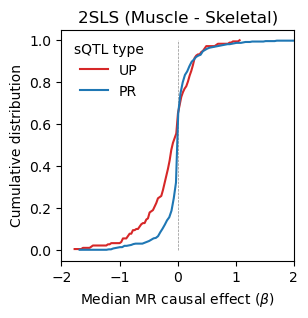

In [ ]:
def get_cumulative(x, steps = 100):
    '''
    Function to get cumulative distribution.
    '''
    x = np.array(x)
    X = np.linspace(np.min(x), np.max(x), steps)
    y = [np.mean(x<=z) for z in X]
    return X, y

def prepare_qq(y_):

    min_non_zero = np.min([x for x in y_ if x > 0])

    y_ = np.maximum(np.array(y_), min_non_zero)
    y = sorted(-np.log10(np.array(y_)))
    x = sorted(-np.log10(np.linspace(1, len(y)+1, len(y))/len(y)))
    return x, y
    
mx_up, my_up = get_cumulative(aver_UP.loc[aver_UP.F >= 10].groupby('gene').intron_gene_beta.median())
mx_pr, my_pr = get_cumulative(aver_PR.loc[aver_PR.F >= 10].groupby('gene').intron_gene_beta.median())


fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(mx_up, my_up, c='tab:red', label='UP')
ax.plot(mx_pr, my_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-2, 2])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal)')


In [ ]:
len(tissues)

# import warnings
# warnings.filterwarnings("ignore")
from tqdm import tqdm

In [ ]:
# mediation_stats_dict = {}
for tissue in tissues:
    aver = get_tissue_mediation_stats(tissue, vcf_in)
    aver['UP'].to_csv(f'MR_2SLS.{tissue}_UP.tab.gz', sep='\t', header=True, index = False)
    aver['PR'].to_csv(f'MR_2SLS.{tissue}_PR.tab.gz', sep='\t', header=True, index = False)

1750it [04:08,  7.04it/s]
5907it [13:22,  7.36it/s]
1363it [02:35,  8.79it/s]
4815it [09:08,  8.79it/s]
665it [00:56, 12.11it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
667it [00:56,  9.48it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
[W::hts_idx_l

In [ ]:
def get_cumulative(x, steps = 100):
    '''
    Function to get cumulative distribution.
    '''
    x = np.array(x)
    X = np.linspace(np.min(x), np.max(x), steps)
    y = [np.mean(x<=z) for z in X]
    return X, y

def prepare_qq(y_):

    min_non_zero = np.min([x for x in y_ if x > 0])

    y_ = np.maximum(np.array(y_), min_non_zero)
    y = sorted(-np.log10(np.array(y_)))
    x = sorted(-np.log10(np.linspace(1, len(y)+1, len(y))/len(y)))
    return x, y
    
mx_up, my_up = get_cumulative(aver['UP'].loc[(aver['UP'].F >= 10) & (aver['UP'].pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
mx_pr, my_pr = get_cumulative(aver['PR'].loc[(aver['PR'].F >= 10) & (aver['PR'].pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())

x_up, y_up = get_cumulative(aver['UP'].loc[aver['UP'].F >= 10].intron_gene_beta)
x_pr, y_pr = get_cumulative(aver['PR'].loc[aver['PR'].F >= 10].intron_gene_beta)



Text(0.5, 1.0, '2SLS (Muscle - Skeletal), eQTL pval <= 1e-10')

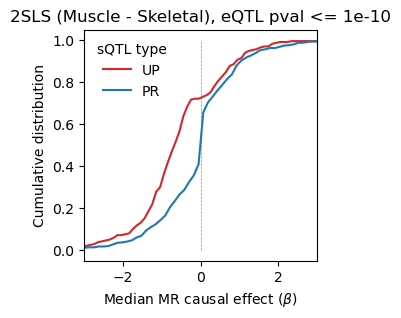

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(mx_up, my_up, c='tab:red', label='UP')
ax.plot(mx_pr, my_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal), eQTL pval <= 1e-10')

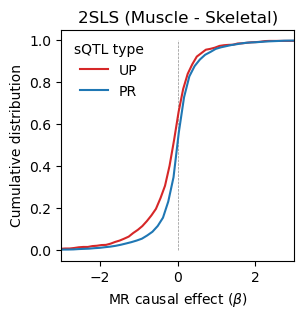

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(x_up, y_up, c='tab:red', label='UP')
ax.plot(x_pr, y_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal)')

plt.savefig('revision_plots/2SLS_muscle.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/2SLS_muscle.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/2SLS_muscle.svg', dpi=300, bbox_inches='tight')   

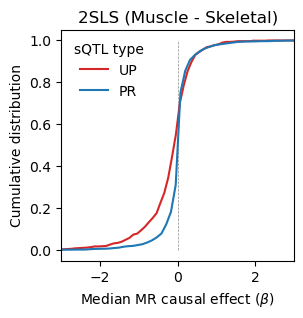

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(mx_up, my_up, c='tab:red', label='UP')
ax.plot(mx_pr, my_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal)')

plt.savefig('revision_plots/2SLS_muscle_median.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/2SLS_muscle_median.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/2SLS_muscle_median.svg', dpi=300, bbox_inches='tight')   

In [ ]:
qqx_up, qqy_up = prepare_qq(aver['UP'].itron_gene_pval)
qqx_pr, qqy_pr = prepare_qq(aver['PR'].itron_gene_pval)

mqqx_up, mqqy_up = prepare_qq(aver['UP'].groupby('gene').itron_gene_pval.median())
mqqx_pr, mqqy_pr = prepare_qq(aver['PR'].groupby('gene').itron_gene_pval.median())

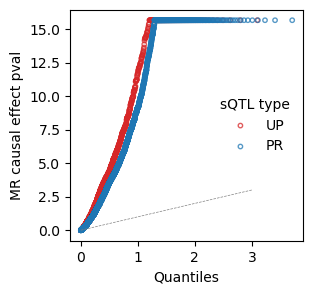

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
# ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
ax.scatter(qqx_up, qqy_up, label=f'UP (n={len(qqx_up)})', facecolor='none', edgecolor = 'tab:red', s=10, alpha=0.75, rasterized=True)
ax.scatter(qqx_pr, qqy_pr, label=f'PR (n={len(qqx_pr)})', facecolor='none', edgecolor = 'tab:blue', s=10, alpha=0.75, rasterized=True)
ax.plot([0, 3], [0, 3], linestyle = '--', linewidth=0.5, c='grey')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
# ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_ylabel(r'MR causal effect pval')
ax.set_xlabel('Quantiles')

plt.savefig('revision_plots/2SLS_muscle_pvals.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/2SLS_muscle_pvals.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/2SLS_muscle_pvals.svg', dpi=300, bbox_inches='tight')   

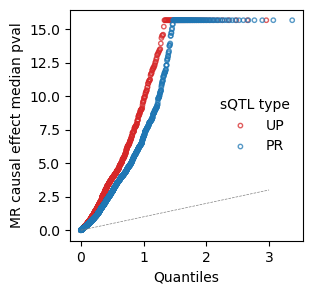

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
# ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
ax.scatter(mqqx_up, mqqy_up, label='UP', facecolor='none', edgecolor = 'tab:red', s=10, alpha=0.75, rasterized=True)
ax.scatter(mqqx_pr, mqqy_pr, label='PR', facecolor='none', edgecolor = 'tab:blue', s=10, alpha=0.75, rasterized=True)
ax.plot([0, 3], [0, 3], linestyle = '--', linewidth=0.5, c='grey')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
# ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_ylabel(r'MR causal effect median pval')
ax.set_xlabel('Quantiles')

plt.savefig('revision_plots/2SLS_muscle_pvals_median.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/2SLS_muscle_pvals_median.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/2SLS_muscle_pvals_median.svg', dpi=300, bbox_inches='tight')   

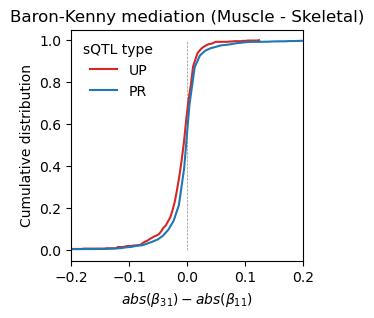

In [ ]:
x_up, y_up = get_cumulative(aver['UP'].loc[aver['UP'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.01].abs_beta_diff)
x_pr, y_pr = get_cumulative(aver['PR'].loc[aver['PR'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.01].abs_beta_diff)

fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
ax.plot(x_up, y_up, c='tab:red', label=f'UP (n={len(x_up)})')
ax.plot(x_pr, y_pr, c='tab:blue', label=f'PR (n={len(x_pr)})')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-0.2, 0.2])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'$abs(\beta_{31}) - abs(\beta_{11})$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('Baron-Kenny mediation (Muscle - Skeletal)')

plt.savefig('revision_plots/BaronKenny_muscle.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/BaronKenny_muscle.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/BaronKenny_muscle.svg', dpi=300, bbox_inches='tight')   

In [ ]:
aver['UP']['beta_diff'] = aver['UP'].beta_3 - aver['UP'].beta_1
aver['UP']['abs_beta_diff'] = aver['UP'].beta_3.abs() - aver['UP'].beta_1.abs()

aver['PR']['beta_diff'] = aver['PR'].beta_3 - aver['PR'].beta_1
aver['PR']['abs_beta_diff'] = aver['PR'].beta_3.abs() - aver['PR'].beta_1.abs()

x_up, y_up = get_cumulative(aver['UP'].loc[aver['UP'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.01].groupby('gene').abs_beta_diff.median())
x_pr, y_pr = get_cumulative(aver['PR'].loc[aver['PR'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.01].groupby('gene').abs_beta_diff.median())

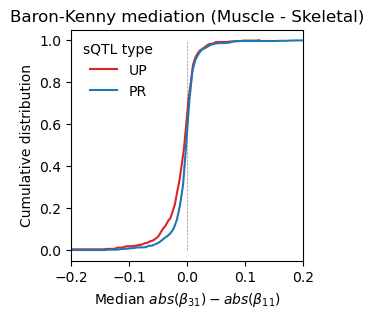

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
ax.plot(x_up, y_up, c='tab:red', label='UP')
ax.plot(x_pr, y_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-0.2, 0.2])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median $abs(\beta_{31}) - abs(\beta_{11})$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('Baron-Kenny mediation (Muscle - Skeletal)')


plt.savefig('revision_plots/BaronKenny_muscle_median.png', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/BaronKenny_muscle_median.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revision_plots/BaronKenny_muscle_median.svg', dpi=300, bbox_inches='tight')  

In [ ]:
aver['UP'].loc[aver['UP'].F >= 50].intron_gene_beta.median()

np.float64(-0.1067309045473313)

In [ ]:
mediation_stats.loc[mediation_stats.F >= 10].groupby('gene').intron_gene_beta.median().median()

In [ ]:
(aver['PR'].loc[aver['PR'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.0001].beta_3.abs() - aver['PR'].loc[aver['PR'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.0001].beta_1.abs()).median()

np.float64(-0.002975570362765398)

In [ ]:
(aver['PR'].beta_3.abs() - aver['PR'].beta_1.abs()).median()

np.float64(-0.0009371020567099046)

In [ ]:
from tqdm import tqdm 
mediation_stats = []
i = 0
for idx, row in tqdm(perm_select.iterrows()):
    try:
        row_stats = process_perm_row(row, 'Muscle-Skeletal', vcf_in)
        mediation_stats.append(row_stats)
    except:
        continue
    # i += 1

    # if i >= 10:
    #     break

mediation_stats = pd.DataFrame(mediation_stats, 
             columns = ['intron', 'gene', 'var', 'F', 'intron_gene_beta', 'itron_gene_pval', 'pval1', 'pval2', 'pval3', 'beta_1', 'beta_3'])

492it [01:21,  5.81it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
493it [01:22,  5.82it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
494it [01:22,  5.80it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutt

In [ ]:
np.median(mediation_stats.loc[mediation_stats[['pval1', 'pval2', 'pval3']].max(axis=1) <= 0.01].beta_3.abs() - mediation_stats.loc[mediation_stats[['pval1', 'pval2', 'pval3']].max(axis=1) <= 0.01].beta_1.abs())

np.float64(-0.005980516796462068)

In [ ]:
mediation_stats.loc[mediation_stats.F >= 10].groupby('gene').intron_gene_beta.median().median()

np.float64(-0.09347670064247329)

In [ ]:
np.median(mediation_stats.beta_1.abs() - mediation_stats.beta_3.abs())

np.float64(0.003346518456521924)

In [ ]:
def get_sqtl_expression_effects(perm_counts, tissue, ctype='PR,UP', itype='UP', qmax = 1e-2, clu_psi_min=0.1):
    sqtl_slopes = []
    eqtl_slopes = []
    eqtl_pvals = []

    perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]
    # idx = perm_counts.loc[(perm_counts.ctype == 'PR,UP') & (perm_counts.itype == 'UP') & (perm_counts.q <= 1e-2)].groupby('gene_id').median_counts.idxmax()
    # perm_select = perm_counts.loc[idx]

#     print(perm_select.columns)
    for idx, row in perm_select.iterrows():
        try:
            eqtl_df = get_expression_effect(tissue, row)
            if eqtl_df.shape[0] > 0:
                eqtl_effect = float(eqtl_df.iloc[0].slope)#/float(eqtl_df.iloc[0].slope_se)
                sqtl_slopes.append(float(row.slope))#/float(row.slope_se))
                eqtl_slopes.append(float(eqtl_effect))
                eqtl_pvals.append(float(eqtl_df.iloc[0].nom_pval))
        except:
            continue
        
    return sqtl_slopes, eqtl_slopes, eqtl_pvals

In [ ]:
# perm_counts = get_perm_counts(tissue)
u_sqtl_effects = get_sqtl_expression_effects(perm_select, 'Muscle-Skeletal', ctype='PR,UP', itype='UP', qmax = 1e-1, clu_psi_min=0.1)
# p_sqtl_effects = get_sqtl_expression_effects(perm_select, tissue, ctype='PR,UP', itype='PR', qmax = 1e-1, clu_psi_min=0.1)
# pp_sqtl_effects = get_sqtl_expression_effects(perm_select, tissue, ctype='PR', itype='PR', qmax = 1e-1, clu_psi_min=0.1)

In [ ]:
iv_df = get_iv_input(stbx, etbx, 'chr1:1915735:1916751:clu_46_+:UP', 'ENSG00000169885', vcf_in, 'chr1_1926870_T_C_b38')

In [ ]:
merged_iv = iv_df.merge(pca.T, left_index = True, right_index=True)

<Axes: xlabel='genotype', ylabel='pheno_intron'>

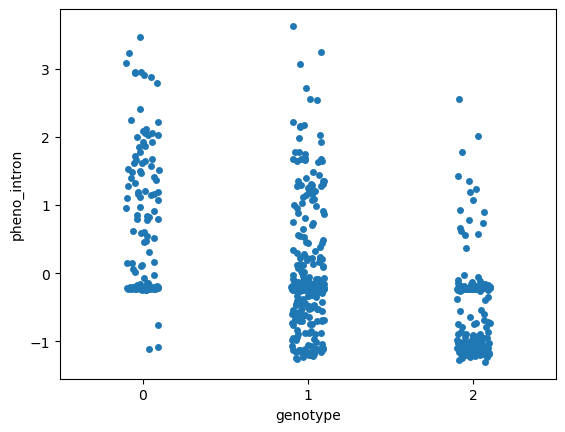

In [ ]:
sns.stripplot(data = merged_iv, x = 'genotype', y = 'pheno_intron')

In [ ]:
get_expression_effect('Muscle-Skeletal', perm_select.iloc[0])

In [ ]:
import statsmodels.api as sm

def baron_kenny_mediation(merged_iv):
    covariates = merged_iv.columns[3:]

    XG_cov   = sm.add_constant(pd.concat([merged_iv['genotype'], merged_iv[covariates]], axis=1))
    XG_I_cov  = sm.add_constant(pd.concat([merged_iv[['genotype', 'pheno_intron']], merged_iv[covariates]], axis=1))

    # Step 1: total genetic effect on expression
    step1 = sm.OLS(merged_iv['pheno_gene'], XG_cov).fit()

    # Step 2: UP splicing path
    step2 = sm.OLS(merged_iv['pheno_intron'], XG_cov).fit()

    # Step 3: mediated analysis
    step3 = sm.OLS(merged_iv['pheno_gene'], XG_I_cov).fit()

    return step1, step2, step3
    
    # print(model_c.summary())
    # print(model_a.summary())
    # print(model_bc.summary())


from linearmodels.iv import IV2SLS

def MR2SLS(merged_iv):
    covariates = merged_iv.columns[3:]
    covs_formula = ' + '.join(covariates)
    formula = 'pheno_gene ~ 1 + ' + covs_formula +' + [pheno_intron ~ genotype]'


    # 2SLS with covariates
    model = IV2SLS.from_formula(
        formula,
        data=merged_iv
    )

    results = model.fit(cov_type='robust')
    return (results)


def get_2SLS_results(merged_iv):
    results = MR2SLS(merged_iv)
    first_stage_F = results.first_stage.diagnostics.loc['pheno_intron', 'f.stat']
    intron_gene_beta = results.params['pheno_intron']
    intron_gene_pval = results.pvalues['pheno_intron']

    return first_stage_F, intron_gene_beta, intron_gene_pval


def get_baron_kenny_results(merged_iv):
    step1, step2, step3 = baron_kenny_mediation(merged_iv)
    pval_1 = step1.pvalues.loc['genotype']
    pval_2 = step2.pvalues.loc['genotype']
    pval_3 = step3.pvalues.loc['genotype']

    beta_step1 = step1.params.loc['genotype']
    beta_step3 = step3.params.loc['genotype']

    return pval_1, pval_2, pval_3, beta_step1, beta_step3

In [ ]:
aver = MR2SLS(merged_iv)

     First Stage Estimation Results    
                           pheno_intron
---------------------------------------
R-squared                        0.5891
Partial R-squared                0.0749
Shea's R-squared                 0.0749
Partial F-statistic              48.125
P-value (Partial F-stat)          4e-12
Partial F-stat Distn            chi2(1)
==========================  ===========
Intercept                        0.8217
                               (6.3458)
PC1                              0.0032
                               (6.9961)
PC2                              0.0120
                               (17.918)
PC3                             -0.0007
                              (-0.8948)
PC4                              0.0086
                               (9.0949)
PC5                             -0.0005
                              (-0.5945)
PC6                             -0.0075
                              (-6.7464)
PC7                             -0.0126


In [ ]:
pca = pd.read_csv('/project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/Muscle-Skeletal/qqnorm.sorted.bed.pca', sep=' ', index_col = 0)

In [ ]:
record_var = fetch_variant(vcf_in, 'chr1_954333_C_A_b38')

In [ ]:
etbx.header[0] == stbx.header[0]

True

In [ ]:
fetch_genotypes(vcf_in, 'chr1_954333_C_A_b38', etbx.header[0].rstrip().split('\t')[6:])

[np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.in